# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [1]:
%load_ext autoreload
%autoreload 2

## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

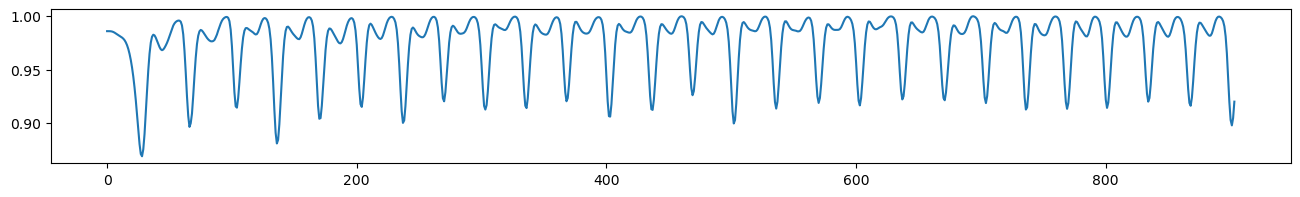

In [3]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

In [4]:
m = 50
mp = stumpy.stump(ts, m=m)
mp

mparray([[2.7408223578420823, 109, -1, 109],
         [2.674516337770923, 110, -1, 110],
         [2.639759265328174, 111, -1, 111],
         ...,
         [0.695465642823645, 688, 688, -1],
         [0.8527226316083207, 689, 689, -1],
         [0.8139831346970323, 256, 256, -1]], dtype=object)

In [5]:
s, c = stumpy.allc(mp[:,2], mp[:,3])

In [8]:
c 

array([ 16,  55, 124, 490, 524, 591])

Найденные индексы обозначают стартовые позиции наиболее протяженной цепочки в временном ряду. Эти точки маркируют начало схожих подшаблонов, формирующих последовательные повторяющиеся фрагменты.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

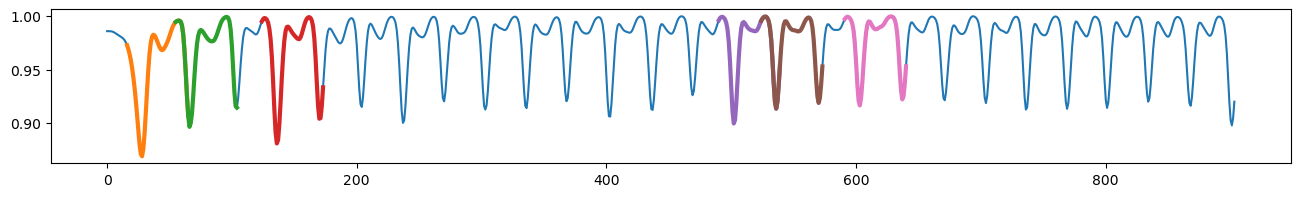

In [9]:
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts)
for i in range(c.shape[0]):
    y = ts[c[i]:c[i]+m]
    x = range(c[i], c[i]+m)
    plt.plot(x, y, linewidth=3)

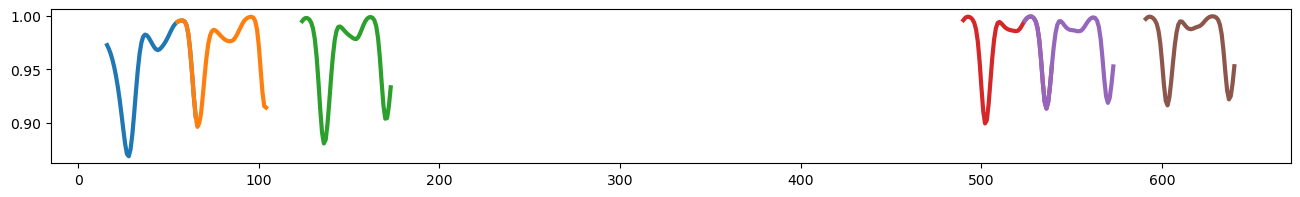

In [10]:
fig, ax = plt.subplots(figsize=(16, 2))
for i in range(c.shape[0]):
    y = ts[c[i]:c[i]+m]
    x = range(c[i], c[i]+m)
    plt.plot(x, y, linewidth=3)

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [24]:
i1 = c[3]
i2 = c[4]
i3 = c[5]

seg1 = ts[i1:i1+m]
seg2 = ts[i2:i2+m]

pred = seg2 + (seg2 - seg1)
real = ts[i3:i3+m]

accuracy = mean_squared_error(real, pred)
print(f"MSE: {accuracy}")

MSE: 2.9289261207411963e-05


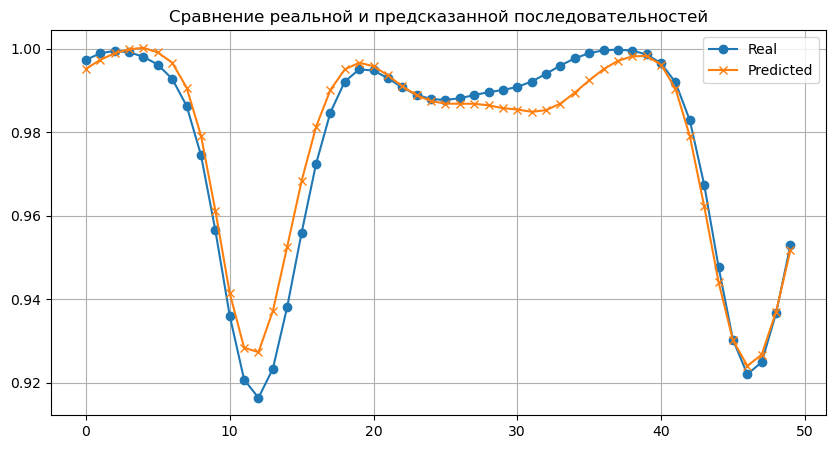

In [27]:
x = range(len(real))

plt.figure(figsize=(10, 5))
plt.plot(x, real, label='Real', marker='o')   
plt.plot(x, pred, label='Predicted', marker='x')  
plt.title('Сравнение реальной и предсказанной последовательностей')
plt.legend()
plt.grid(True)
plt.show()

Визуальное сопоставление фактических и прогнозных значений демонстрирует высокую степень соответствия между двумя временными сегментами. Успешность прогнозирования объясняется наличием устойчивых паттернов в данных, где разность между соседними элементами сохраняет предсказуемый характер.